Preprocessing

In [23]:
import pandas as pd  
import numpy as np


In [24]:
Data = pd.read_csv("adults.csv")


y_raw = Data['hours-per-week']
x_raw = Data
x_raw.drop('education-num', axis=1, inplace=True)
x_raw.drop('income', axis=1, inplace=True)
print(x_raw.shape)
print(y_raw.shape)


(48842, 13)
(48842,)


In [25]:
# x_raw = x_raw.replace("?", np.nan)
# x_raw[pd.isnull(x_raw).any(axis=1)].shape
# rows_with_missing_values = x_raw[pd.isnull(x_raw).any(axis=1)]

# x_raw.dropna(inplace=True)
# x_raw.drop('education-num', axis=1, inplace=True)
# y_raw = y_raw.drop(rows_with_missing_values.index)


In [26]:
# x = pd.DataFrame(x_raw)
# y = pd.DataFrame(y_raw)
# x_names = x.columns.tolist()
# x_names = np.array(x_names)
# y_names = y.columns.tolist()
x = x_raw
y = y_raw

In [27]:
#print(x[10:60])
print(x['workclass'][x['workclass'] == '?'])

x['workclass'], value = pd.factorize(x_raw['workclass'])
print("1",value)
x['education'], value = pd.factorize(x_raw['education'])
print("2",value)
x['marital-status'], value = pd.factorize(x_raw['marital-status'])
print("3",value)
x['occupation'], value = pd.factorize(x_raw['occupation'])
print("4",value)
x['relationship'], value = pd.factorize(x_raw['relationship'])
print("5",value)
x['race'], value = pd.factorize(x_raw['race'])
print("6",value)
x['sex'], value = pd.factorize(x_raw['sex'])
print("7",value)
x['native-country'], value = pd.factorize(x_raw['native-country'])
print("9",value)


#print(x)

Series([], Name: workclass, dtype: object)
1 Index([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay', ' Never-worked'],
      dtype='object')
2 Index([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th', ' Some-college',
       ' Assoc-acdm', ' Assoc-voc', ' 7th-8th', ' Doctorate', ' Prof-school',
       ' 5th-6th', ' 10th', ' 1st-4th', ' Preschool', ' 12th'],
      dtype='object')
3 Index([' Never-married', ' Married-civ-spouse', ' Divorced',
       ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
       ' Widowed'],
      dtype='object')
4 Index([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', ' ?', ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'],
      dtype='object')
5 Index([' Not-in-family', ' Husband', '

In [28]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x['age'] = scaler.fit_transform(x[['age']])
x['fnlwgt'] = scaler.fit_transform(x[['fnlwgt']])
x['capital-gain'] = scaler.fit_transform(x[['capital-gain']])
x['capital-loss'] = scaler.fit_transform(x[['capital-loss']])

y = scaler.fit_transform(y.values.reshape(-1, 1))



SVR


In [29]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=0)


In [30]:
%matplotlib widget
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

rmse = []
mape = []
r2 = []
for train_index, test_index in kf.split(x):
    x_train = x.loc[train_index]
    x_test = x.loc[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    model = SVR(C=1.0, epsilon=0.2)
    model.fit(x_train,y_train.ravel())

    pred_test = model.predict(x_test)

    print("Test Score:")
    mape.append(mean_absolute_percentage_error(y_test, pred_test))
    rmse.append(mean_squared_error(y_test, pred_test, squared=False))
    r2.append(r2_score(y_test, pred_test))

    print("Mean Absolute Error: " ,mean_absolute_percentage_error(y_test, pred_test))
    print("Mean Squared Error: " ,mean_squared_error(y_test, pred_test))
    print("R2 Score: " ,r2_score(y_test, pred_test))

    print("Train Index:", train_index)
    print("Test Index:", test_index)
    print("-----")



Test Score:
Mean Absolute Error:  549447532047.49554
Mean Squared Error:  0.0012415236327697546
R2 Score:  0.919376391374874
Train Index: [    0     1     2 ... 48839 48840 48841]
Test Index: [    3     6    17 ... 48830 48837 48838]
-----
Test Score:
Mean Absolute Error:  721237776798.9126
Mean Squared Error:  0.0013088966092709572
R2 Score:  0.9173963459601417
Train Index: [    0     1     2 ... 48837 48838 48840]
Test Index: [    4     9    14 ... 48832 48839 48841]
-----
Test Score:
Mean Absolute Error:  360645619927.27234
Mean Squared Error:  0.0012387080380216193
R2 Score:  0.9204915088950743
Train Index: [    1     2     3 ... 48839 48840 48841]
Test Index: [    0     7     8 ... 48829 48834 48835]
-----
Test Score:
Mean Absolute Error:  448127108839.1171
Mean Squared Error:  0.001324657795639977
R2 Score:  0.9217506824157985
Train Index: [    0     3     4 ... 48838 48839 48841]
Test Index: [    1     2     5 ... 48831 48833 48840]
-----
Test Score:
Mean Absolute Error:  364161

In [31]:
print("Mean Absolute Percentage Error:", np.mean(mape))
print("Root Mean Squared Error:", np.mean(rmse))
print("R2 Score:", np.mean(r2))

Mean Absolute Percentage Error: 488723945999.5033
Root Mean Squared Error: 0.035975051059572785
R2 Score: 0.9190028964599121


0.7419533438916212 [0.80612245]
0.40898146522054085 [0.39795918]
0.4955288093857919 [0.5]
0.4532666502289907 [0.44897959]
0.2603912604633365 [0.19387755]
0.410955338982647 [0.39795918]
0.5123974283229418 [0.52040816]
0.4116520587752773 [0.39795918]
0.41267472546477796 [0.39795918]
0.4356664743613344 [0.42857143]
0.5874205817764813 [0.60204082]
0.4098708102904979 [0.39795918]
0.4527142273339364 [0.44897959]
0.40990313170062603 [0.39795918]
0.40643434866409 [0.39795918]
0.20032634903764923 [0.01020408]
0.33003675042531766 [0.29591837]
0.4101866831059751 [0.39795918]
0.363633472524743 [0.34693878]
0.49549011770892754 [0.5]
0.41119044942278793 [0.39795918]
0.4112027032748218 [0.39795918]
0.4954143429619994 [0.5]
0.41073641846888925 [0.39795918]
0.34857572382687196 [0.31632653]
0.41152262389927174 [0.39795918]
0.41272904268966687 [0.39795918]
0.4121465929204984 [0.39795918]
0.4108496875469975 [0.39795918]
0.2897206817109743 [0.24489796]
0.40939785789957656 [0.39795918]
0.4102209811791801 [0

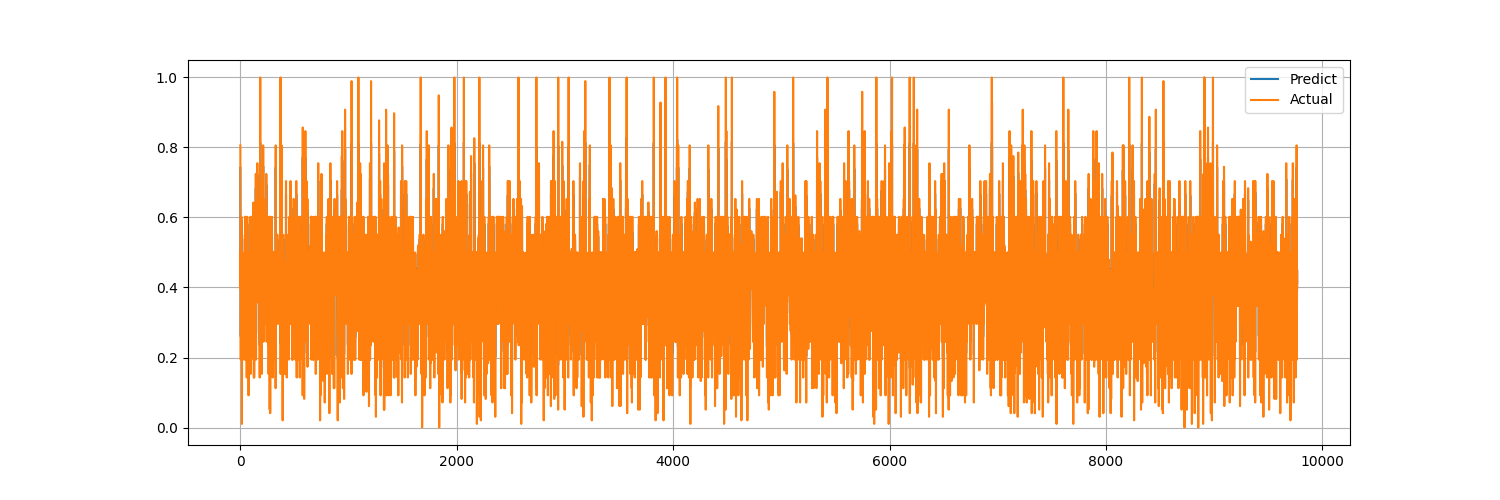

In [32]:
import matplotlib.pyplot as plt

for i in range(len(y_test)):
    print(pred_test[i],y_test[i])

fig = plt.figure(figsize=(15,5))
plt.plot(pred_test,label = 'Predict')
plt.plot(np.array(y_test),label = 'Actual')
plt.grid()
plt.legend()
plt.show()